<div style="overflow:hidden;border-radius:20px;">
<img src="1-miku.jpg"
     style="
     width:100%;
     height:250px;
     object-fit:cover;
     ">
    <h1 align="center">🌸 Anime Recommendation System</h1>
    <p align="center">Content-Based Recommendation using Jikan API</p>
</div>



# 📖 Project Overview

This project collects anime data from the Jikan API, cleans the dataset, and performs exploratory data analysis to prepare for a recommendation system.


In [1]:
!pip install seaborn
!pip install scikit-learn
!pip install hdbscan
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns #or sb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

In [2]:
url = "https://api.jikan.moe/v4/anime"

response = requests.get(url)

print(response.status_code)

200


In [3]:
data = response.json()

print(type(data))

<class 'dict'>


In [4]:
data.keys()

dict_keys(['pagination', 'data'])

In [5]:
first_anime = data["data"][0]

first_anime

{'mal_id': 1,
 'url': 'https://myanimelist.net/anime/1/Cowboy_Bebop',
 'images': {'jpg': {'image_url': 'https://cdn.myanimelist.net/images/anime/4/19644.jpg',
   'small_image_url': 'https://cdn.myanimelist.net/images/anime/4/19644t.jpg',
   'large_image_url': 'https://cdn.myanimelist.net/images/anime/4/19644l.jpg'},
  'webp': {'image_url': 'https://cdn.myanimelist.net/images/anime/4/19644.webp',
   'small_image_url': 'https://cdn.myanimelist.net/images/anime/4/19644t.webp',
   'large_image_url': 'https://cdn.myanimelist.net/images/anime/4/19644l.webp'}},
 'trailer': {'youtube_id': None,
  'url': None,
  'embed_url': 'https://www.youtube-nocookie.com/embed/gY5nDXOtv_o?enablejsapi=1&wmode=opaque&autoplay=1',
  'images': {'image_url': None,
   'small_image_url': None,
   'medium_image_url': None,
   'large_image_url': None,
   'maximum_image_url': None}},
 'approved': True,
 'titles': [{'type': 'Default', 'title': 'Cowboy Bebop'},
  {'type': 'Japanese', 'title': 'カウボーイビバップ'},
  {'type': '

In [6]:
print(first_anime["title"])
print(first_anime["score"])
print(first_anime["episodes"])

Cowboy Bebop
8.75
26


In [7]:
anime_list = []

for anime in data["data"]:

    anime_info = {
    "title": anime["title"],
    "score": anime["score"],
    "episodes": anime["episodes"],
    "rank": anime["rank"],
    "popularity": anime["popularity"],
    "year": anime["year"],
    "synopsis": anime["synopsis"],
}

    anime_list.append(anime_info)

anime_list[:3]

[{'title': 'Cowboy Bebop',
  'score': 8.75,
  'episodes': 26,
  'rank': 48,
  'popularity': 41,
  'year': 1998,
  'synopsis': "Crime is timeless. By the year 2071, humanity has expanded across the galaxy, filling the surface of other planets with settlements like those on Earth. These new societies are plagued by murder, drug use, and theft, and intergalactic outlaws are hunted by a growing number of tough bounty hunters.\n\nSpike Spiegel and Jet Black pursue criminals throughout space to make a humble living. Beneath his goofy and aloof demeanor, Spike is haunted by the weight of his violent past. Meanwhile, Jet manages his own troubled memories while taking care of Spike and the Bebop, their ship. The duo is joined by the beautiful con artist Faye Valentine, odd child Edward Wong Hau Pepelu Tivrusky IV, and Ein, a bioengineered Welsh corgi.\n\nWhile developing bonds and working to catch a colorful cast of criminals, the Bebop crew's lives are disrupted by a menace from Spike's past. 

In [8]:
df = pd.DataFrame(anime_list)

df.head()

,title,score,episodes,rank,popularity,year,synopsis
0,Cowboy Bebop,8.75,26.0,48,41,1998.0,"Crime is timeless. By the year 2071, humanity ..."
1,Cowboy Bebop: Tengoku no Tobira,8.38,1.0,238,659,NaN,"Another day, another bounty—such is the life o..."
2,Trigun,8.22,26.0,416,266,1998.0,"Vash the Stampede is the man with a $$60,000,0..."
3,Witch Hunter Robin,7.24,26.0,3455,1997,2002.0,"Though hidden away from the general public, Wi..."
4,Bouken Ou Beet,6.96,52.0,4913,5931,2004.0,It is the dark century and the people are suff...


In [9]:
df.to_csv(
    "C:/Users/Arian/OneDrive/Documents/OneDrive/Desktop/anime-recommendation-system/anime.csv",
    index=False
)

<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

#  Data Collection


</div>

In [10]:
all_anime = []

for page in range(1,11):

    url = f"https://api.jikan.moe/v4/anime?page={page}"

    response = requests.get(url)

    data = response.json()

    for anime in data["data"]:

        all_anime.append({
            "title": anime["title"],
            "score": anime["score"],
            "episodes": anime["episodes"],
            "rank": anime["rank"],
            "popularity": anime["popularity"],
            "year": anime["year"],
            "synopsis": anime["synopsis"],
        })

    time.sleep(1)

In [11]:
df = pd.DataFrame(all_anime)

print(df.shape)

df.head()


(250, 7)


,title,score,episodes,rank,popularity,year,synopsis
0,Cowboy Bebop,8.75,26.0,48.0,41,1998.0,"Crime is timeless. By the year 2071, humanity ..."
1,Cowboy Bebop: Tengoku no Tobira,8.38,1.0,238.0,659,NaN,"Another day, another bounty—such is the life o..."
2,Trigun,8.22,26.0,416.0,266,1998.0,"Vash the Stampede is the man with a $$60,000,0..."
3,Witch Hunter Robin,7.24,26.0,3455.0,1997,2002.0,"Though hidden away from the general public, Wi..."
4,Bouken Ou Beet,6.96,52.0,4913.0,5931,2004.0,It is the dark century and the people are suff...


In [12]:
#debug
df.to_csv(
    "anime.csv",
    index=False
)

In [13]:
df = pd.read_csv(
    "anime.csv"
)

df.head()

,title,score,episodes,rank,popularity,year,synopsis
0,Cowboy Bebop,8.75,26.0,48.0,41,1998.0,"Crime is timeless. By the year 2071, humanity ..."
1,Cowboy Bebop: Tengoku no Tobira,8.38,1.0,238.0,659,NaN,"Another day, another bounty—such is the life o..."
2,Trigun,8.22,26.0,416.0,266,1998.0,"Vash the Stampede is the man with a $$60,000,0..."
3,Witch Hunter Robin,7.24,26.0,3455.0,1997,2002.0,"Though hidden away from the general public, Wi..."
4,Bouken Ou Beet,6.96,52.0,4913.0,5931,2004.0,It is the dark century and the people are suff...


### ✅ Collection Summary

The dataset was successfully collected and converted into a DataFrame.


In [14]:
genres = []

for g in anime["genres"]:
    genres.append(g["name"])

In [15]:
print(df.columns)

Index(['title', 'score', 'episodes', 'rank', 'popularity', 'year', 'synopsis'], dtype='object')


In [16]:
df.isnull().sum()

title          0
score          0
episodes       2
rank           8
popularity     0
year          61
synopsis       0
dtype: int64

In [17]:
print(df.columns)

Index(['title', 'score', 'episodes', 'rank', 'popularity', 'year', 'synopsis'], dtype='object')





<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 🧹 Data Cleaning

Removing missing values and duplicate entries to improve data quality.

</div>

In [18]:
df = df.dropna(
    subset=["synopsis"]
)

In [19]:
df = df.drop_duplicates()

In [20]:
df = df.dropna(subset=["synopsis"])

In [21]:
df.to_csv(
    "anime.csv",
    index=False
)

In [22]:
print(df.shape)

print(df.columns)

df.head()

(250, 7)
Index(['title', 'score', 'episodes', 'rank', 'popularity', 'year', 'synopsis'], dtype='object')


,title,score,episodes,rank,popularity,year,synopsis
0,Cowboy Bebop,8.75,26.0,48.0,41,1998.0,"Crime is timeless. By the year 2071, humanity ..."
1,Cowboy Bebop: Tengoku no Tobira,8.38,1.0,238.0,659,NaN,"Another day, another bounty—such is the life o..."
2,Trigun,8.22,26.0,416.0,266,1998.0,"Vash the Stampede is the man with a $$60,000,0..."
3,Witch Hunter Robin,7.24,26.0,3455.0,1997,2002.0,"Though hidden away from the general public, Wi..."
4,Bouken Ou Beet,6.96,52.0,4913.0,5931,2004.0,It is the dark century and the people are suff...


<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

### ✅ Cleaning Summary

The dataset is now cleaner and ready for analysis.



</div>




<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 📊 Exploratory Data Analysis

Analyzing rating, popularity, and release trends within the dataset.


</div>

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       250 non-null    object 
 1   score       250 non-null    float64
 2   episodes    248 non-null    float64
 3   rank        242 non-null    float64
 4   popularity  250 non-null    int64  
 5   year        189 non-null    float64
 6   synopsis    250 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 13.8+ KB


In [24]:
df = df.dropna(subset=["synopsis"])

print(df.shape)

(250, 7)


In [25]:
print(df.shape)

print(df.isnull().sum())

df.head()

(250, 7)
title          0
score          0
episodes       2
rank           8
popularity     0
year          61
synopsis       0
dtype: int64


,title,score,episodes,rank,popularity,year,synopsis
0,Cowboy Bebop,8.75,26.0,48.0,41,1998.0,"Crime is timeless. By the year 2071, humanity ..."
1,Cowboy Bebop: Tengoku no Tobira,8.38,1.0,238.0,659,NaN,"Another day, another bounty—such is the life o..."
2,Trigun,8.22,26.0,416.0,266,1998.0,"Vash the Stampede is the man with a $$60,000,0..."
3,Witch Hunter Robin,7.24,26.0,3455.0,1997,2002.0,"Though hidden away from the general public, Wi..."
4,Bouken Ou Beet,6.96,52.0,4913.0,5931,2004.0,It is the dark century and the people are suff...


In [26]:
df["episodes"].isna().sum()

np.int64(2)

In [27]:
df["episodes"] = df["episodes"].fillna(
    df["episodes"].median()
)

In [28]:
df["rank"].isna().sum()

np.int64(8)

In [29]:
df["rank"] = df["rank"].fillna(
    df["rank"].median()
)

In [30]:
df["year"].isna().sum()

np.int64(61)

In [31]:
df["year"] = df["year"].fillna(
    df["year"].median()
)

In [32]:
df.isnull().sum()

title         0
score         0
episodes      0
rank          0
popularity    0
year          0
synopsis      0
dtype: int64



<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 📈 Statistical Summary

Basic statistics provide an overview of the dataset.


</div>

In [33]:
df.describe()

,score,episodes,rank,popularity,year
count,250.000000,250.00000,250.000000,250.000000,250.000000
mean,7.317920,28.06000,3474.832000,3180.556000,2001.828000
std,0.675613,37.37029,2790.316251,2505.365061,3.511086
min,4.880000,1.00000,26.000000,9.000000,1979.000000
25%,6.800000,12.00000,1204.500000,1375.500000,2001.000000
50%,7.350000,24.00000,2780.000000,2570.500000,2003.000000
75%,7.780000,26.00000,5207.000000,4638.750000,2004.000000
max,8.890000,366.00000,14457.000000,11182.000000,2005.000000


In [34]:
plt.style.use("dark_background")

PINK = "#ff66b2"
CYAN = "#00e5ff"
PURPLE = "#a855f7"
YELLOW = "#ffd93d"

<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# ⭐ Score Distribution

Distribution of anime ratings.


</div>

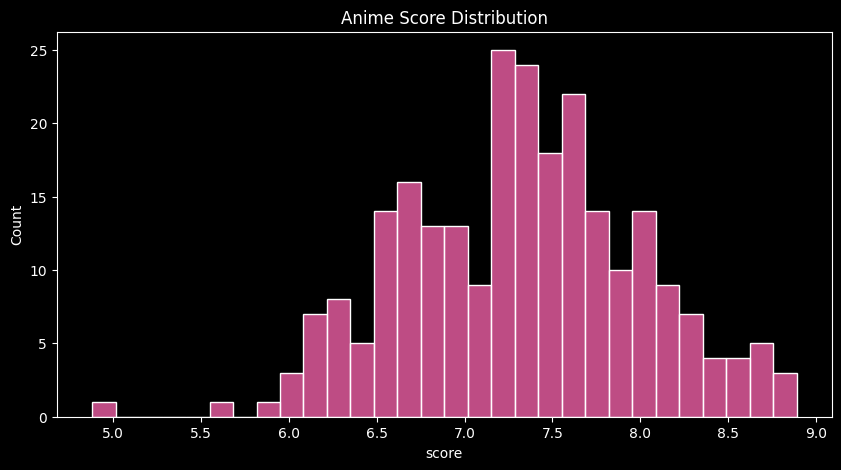

In [35]:
plt.style.use('dark_background')
plt.figure(figsize=(10,5))

sns.histplot(
    df["score"],
    bins=30,
    color=PINK,
    edgecolor="white"
)

plt.title("Anime Score Distribution")

plt.show()



<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">
### 🎯 Conclusion

Most anime are concentrated around medium to high scores.



</div>

<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 📝 Synopsis Preview

Checking anime descriptions before feature engineering.


</div>

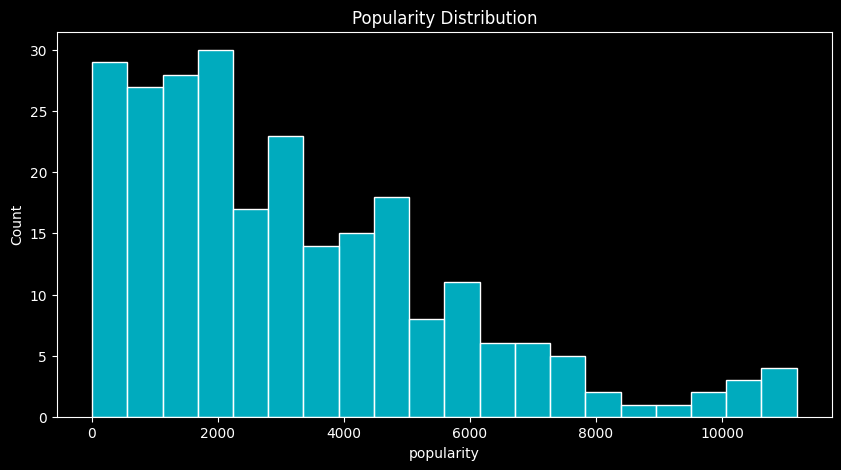

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["popularity"],
    bins=20,
    color=CYAN
)

plt.title("Popularity Distribution")

plt.show()

In [37]:
print(df.shape)

print(df["synopsis"].head(3))

(250, 7)
0    Crime is timeless. By the year 2071, humanity ...
1    Another day, another bounty—such is the life o...
2    Vash the Stampede is the man with a $$60,000,0...
Name: synopsis, dtype: object



<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 📦 Score Boxplot

Visualizing score spread and outliers.



</div>

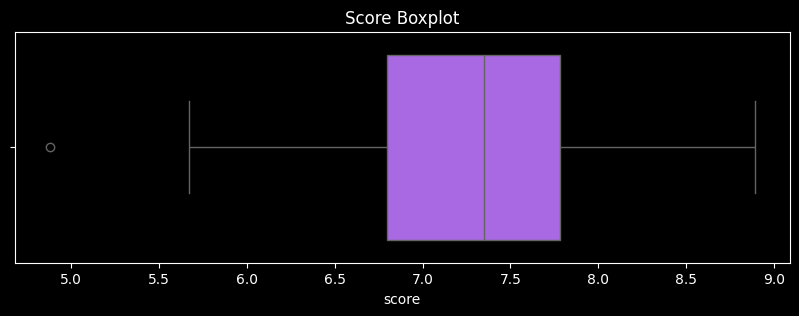

In [38]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["score"],
    color=PURPLE
)

plt.title("Score Boxplot")

plt.show()



<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

### 🎯 Conclusion

Most ratings fall within a narrow range with few outliers.



</div>



<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">
    
# 📅 Anime Releases by Year

Number of anime released over time.


</div>

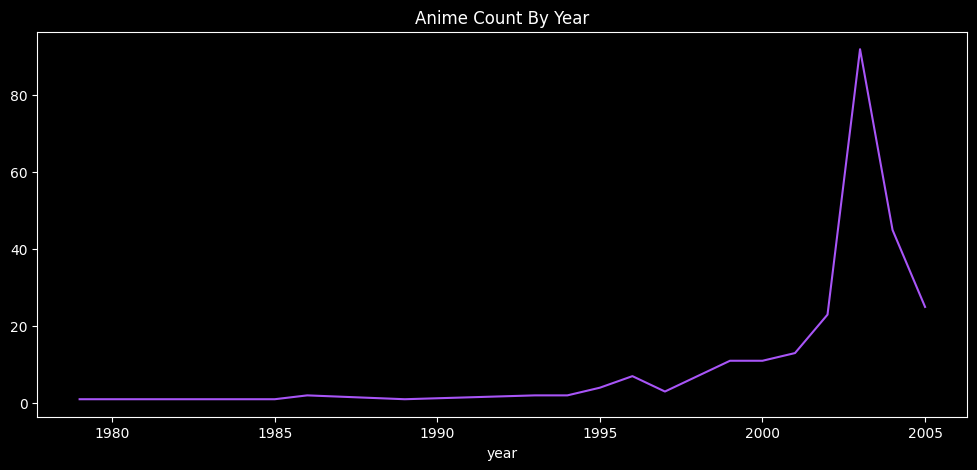

In [39]:
df["year"].value_counts()\
.sort_index()\
.plot(
    figsize=(12,5),
    color=PURPLE
)
plt.title("Anime Count By Year")

plt.show()


<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 🔥 Popularity vs Score

Relationship between popularity and rating.


</div>

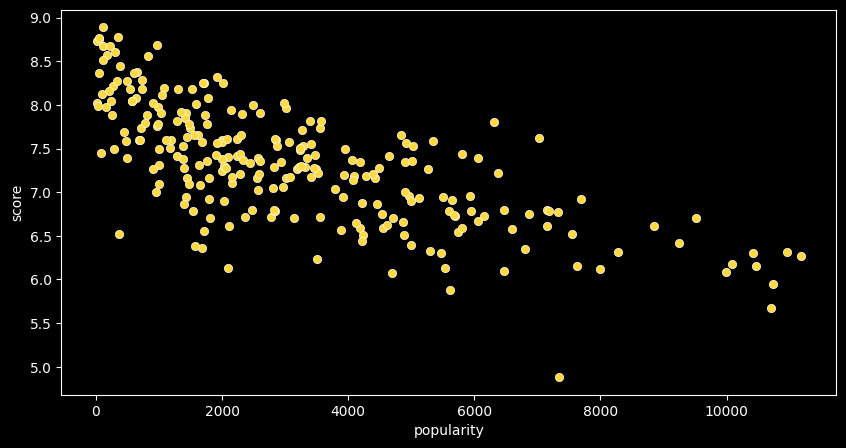

In [40]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df["popularity"],
    y=df["score"],
    color=YELLOW
)

plt.show()


<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

### 🎯 Conclusion

Popularity does not always correspond to higher ratings.

</div>

# ⚙️ Feature Matrix

Numerical features are selected for clustering and classification tasks.
These variables describe anime popularity, ranking, release year, and episode count.

In [41]:
features = [
    "score",
    "episodes",
    "rank",
    "popularity",
    "year"
]

X = df[features]

X.head()

,score,episodes,rank,popularity,year
0,8.75,26.0,48.0,41,1998.0
1,8.38,1.0,238.0,659,2003.0
2,8.22,26.0,416.0,266,1998.0
3,7.24,26.0,3455.0,1997,2002.0
4,6.96,52.0,4913.0,5931,2004.0


# 📏 Feature Scaling

Machine learning algorithms are sensitive to feature magnitude.
Standardization ensures fair contribution from all variables.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 🌌 KMeans Clustering

KMeans groups anime into clusters based on synopsis similarity.
The model identifies hidden structures without using labels.

# Elbow Method
</div>

In [43]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42
)

In [44]:
clusters = kmeans.fit_predict(X)

In [45]:
df["kmeans_cluster"] = kmeans.fit_predict(
    X_scaled
)

In [46]:
plt.style.use("dark_background")

sns.set_context(
    "talk"
)

sns.set_palette(
    "husl"
)

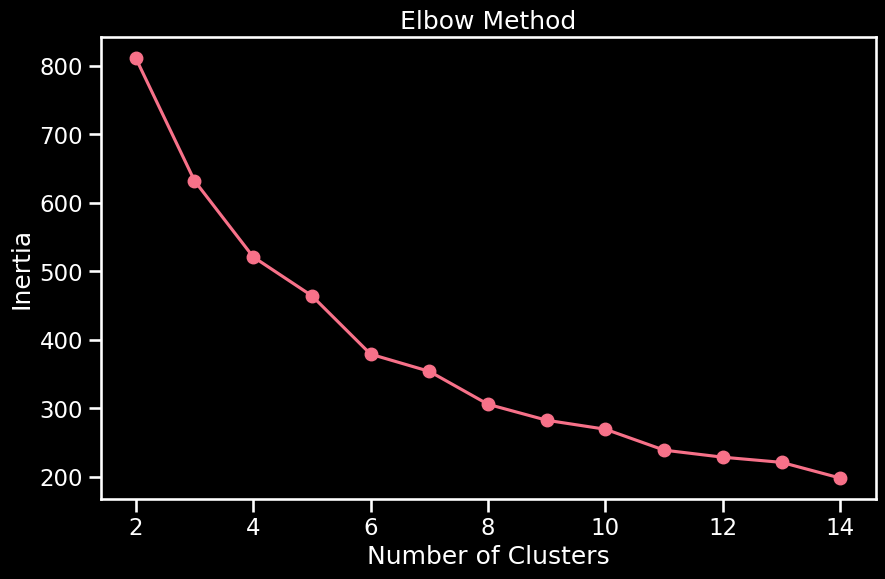

In [47]:
inertia = []

for k in range(2,15):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

plt.figure(figsize=(10,6))

plt.plot(
    range(2,15),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [48]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">
## Conclusion

The elbow point indicates an appropriate number of clusters for the dataset.

</div>




<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">
    
# 🌳 Hierarchical Clustering Dendrogram

The dendrogram illustrates hierarchical relationships among anime titles.
Similar anime are merged together at lower distances.


</div>

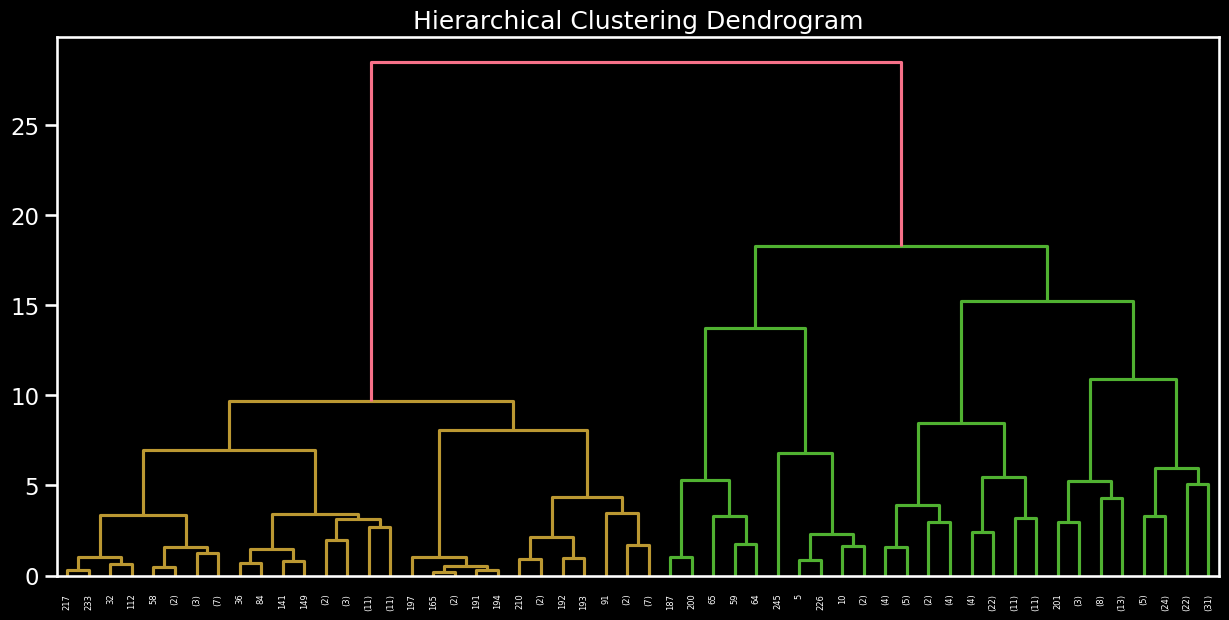

In [49]:
linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(15,7))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()

<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

## Conclusion

The tree structure reveals how anime groups are progressively formed.




</div>

<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">
    
# 🔍 DBSCAN Cluster Visualization

DBSCAN identifies dense regions and detects outlier anime.
Noise points are labeled separately.





</div>

In [50]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=3
)

dbscan_clusters = dbscan.fit_predict(
    X_scaled
)

df["dbscan_cluster"] = dbscan_clusters

df["dbscan_cluster"].value_counts()



dbscan_cluster
 0    231
-1      9
 2      6
 1      4
Name: count, dtype: int64

In [51]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

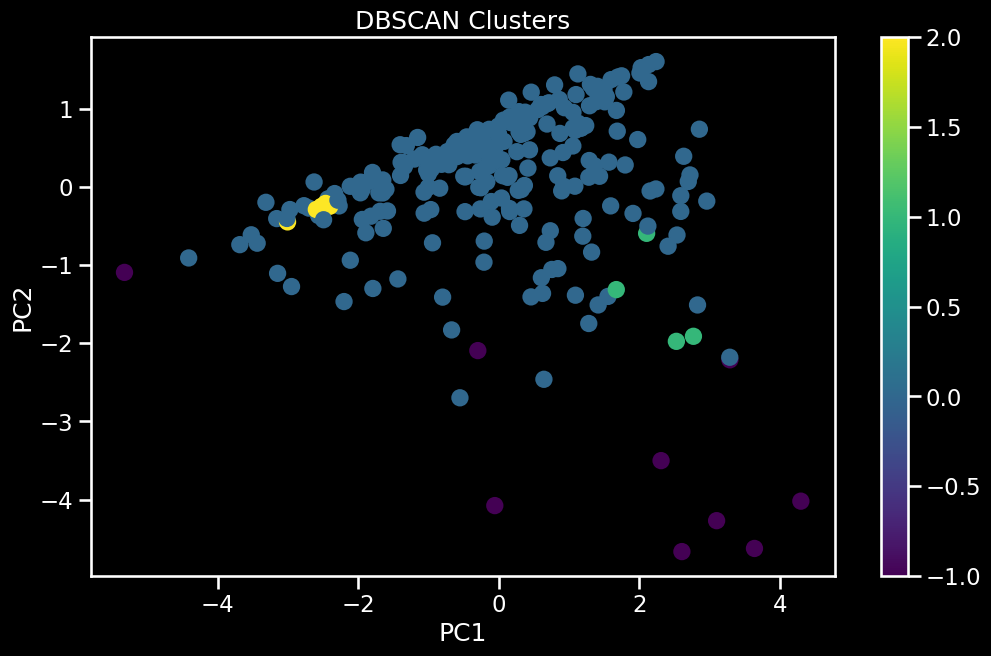

In [52]:
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["dbscan_cluster"],
    s=120
)

plt.title(
    "DBSCAN Clusters"
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.colorbar(scatter)

plt.show()


<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

## Conclusion

Several dense clusters were identified, while unusual anime were treated as noise.

</div>

<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 🚀 HDBSCAN Cluster Visualization

HDBSCAN automatically discovers cluster structures with varying densities.


</div>

In [53]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3
)


hdbscan_clusters = clusterer.fit_predict(
    X_scaled
)


df["hdbscan_cluster"] = hdbscan_clusters
df["hdbscan_cluster"].value_counts()

hdbscan_cluster
 2    229
-1     11
 1      6
 0      4
Name: count, dtype: int64

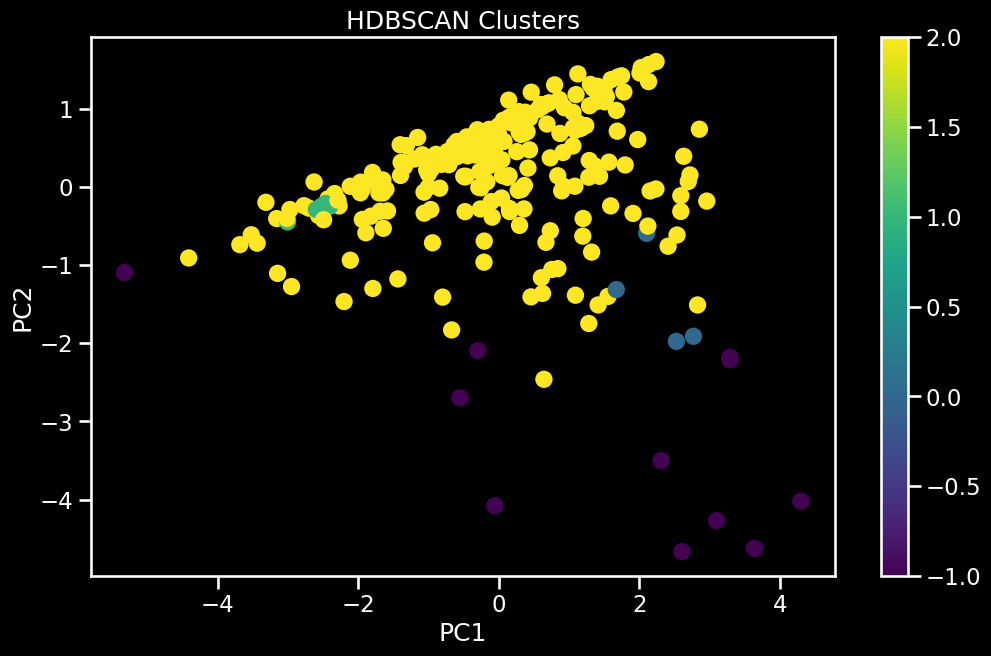

In [54]:
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["hdbscan_cluster"],
    s=120
)

plt.title(
    "HDBSCAN Clusters"
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.colorbar(scatter)

plt.show()


<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

## Conclusion

The algorithm detected flexible cluster patterns without requiring a fixed cluster count.

</div>

<div style="
background:linear-gradient(90deg,#FFF4EC,#FFE7D6);
padding:15px;
border-radius:15px;
border-left:6px solid #FF4500;
color:#5A3A2B;
">
    
# 🎨 PCA Visualization

Principal Component Analysis reduces dimensionality while preserving information.
The resulting visualization helps interpret cluster structures.

</div>

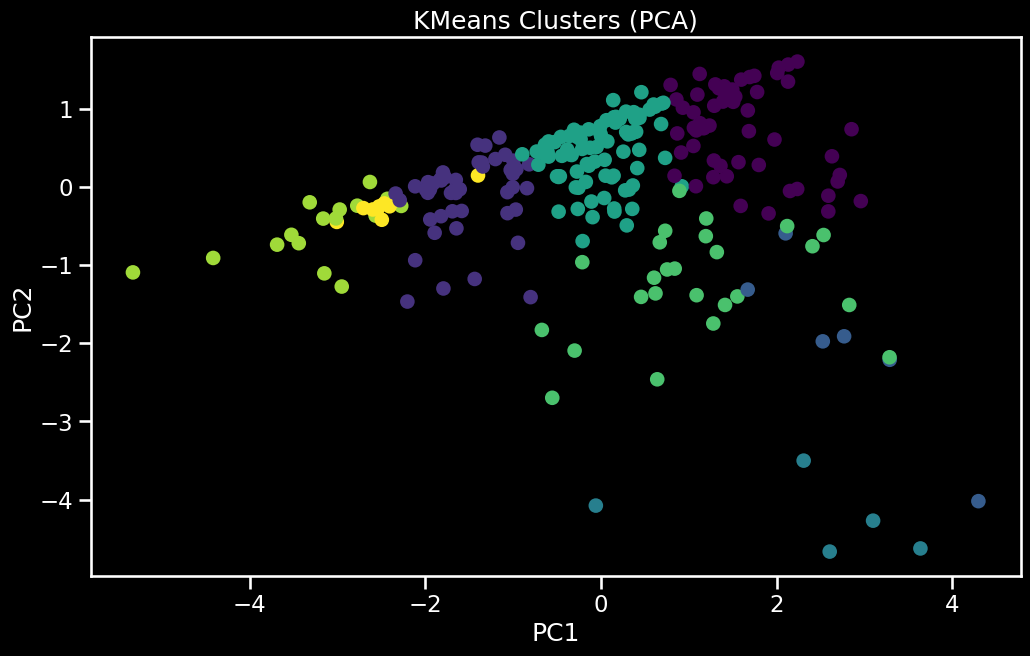

In [55]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(12,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["kmeans_cluster"]
)

plt.title(
    "KMeans Clusters (PCA)"
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.show()

<div style="
background:linear-gradient(90deg,#FFF4EC,#FFE7D6);
padding:15px;
border-radius:15px;
border-left:6px solid #FF4500;
color:#5A3A2B;
">

## Conclusion

Cluster separation becomes easier to interpret in a two-dimensional space.

</div>

In [56]:
df.shape

df.columns

df.head()

,title,score,episodes,rank,popularity,year,synopsis,kmeans_cluster,dbscan_cluster,hdbscan_cluster
0,Cowboy Bebop,8.75,26.0,48.0,41,1998.0,"Crime is timeless. By the year 2071, humanity ...",0,0,2
1,Cowboy Bebop: Tengoku no Tobira,8.38,1.0,238.0,659,2003.0,"Another day, another bounty—such is the life o...",0,0,2
2,Trigun,8.22,26.0,416.0,266,1998.0,"Vash the Stampede is the man with a $$60,000,0...",0,0,2
3,Witch Hunter Robin,7.24,26.0,3455.0,1997,2002.0,"Though hidden away from the general public, Wi...",4,0,2
4,Bouken Ou Beet,6.96,52.0,4913.0,5931,2004.0,It is the dark century and the people are suff...,1,0,2


In [57]:
df["dbscan_cluster"].value_counts()

dbscan_cluster
 0    231
-1      9
 2      6
 1      4
Name: count, dtype: int64

In [58]:
df["hdbscan_cluster"].value_counts()

hdbscan_cluster
 2    229
-1     11
 1      6
 0      4
Name: count, dtype: int64

In [59]:
df.shape

(250, 10)

# this is the end 
## unsupervised

<div style="
background:linear-gradient(90deg,#F8F9FA,#ECEDEF);
padding:15px;
border-radius:15px;
border-left:6px solid #0071E3;
color:#2D3748;
">

# Supervised Learning

</div>

<div style="
background:linear-gradient(90deg,#FFF8E1,#FFF2C2);
padding:15px;
border-radius:15px;
border-left:6px solid #D4AF37;
color:#5A4720;
">

# 🏷️ Creating Target Variable

A binary target variable is generated from anime scores.
Anime with scores greater than or equal to 8 are labeled as high-rated.

</div>

In [60]:
df["high_rated"] = (
    df["score"] >= 8
).astype(int)

df["high_rated"].value_counts()

high_rated
0    208
1     42
Name: count, dtype: int64

<!-- Sakura Pink -->

<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

# 📊 Target Distribution

The distribution of high-rated and low-rated anime is visualized.
Balanced classes generally improve model performance.

</div>

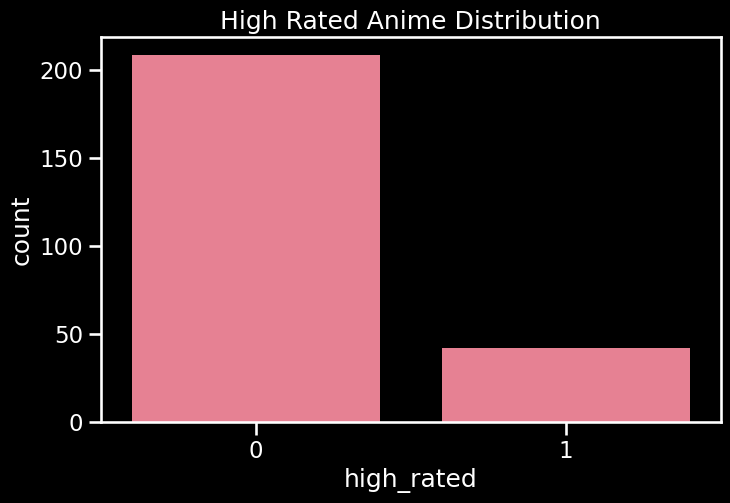

In [61]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="high_rated",
    data=df
)

plt.title(
    "High Rated Anime Distribution"
)

plt.show()

<!-- Sakura Pink -->

<div style="
background:linear-gradient(90deg,#FFF5F7,#FDEBF1);
padding:15px;
border-radius:15px;
border-left:6px solid #D98FB3;
color:#5C4B51;
">

## Conclusion

The chart shows the proportion of high-rated and lower-rated anime.
Class balance should be considered during model training.

</div>

<!-- Discord Green -->

<div style="
background:linear-gradient(90deg,#F0FFF6,#FFFBEA);
padding:15px;
border-radius:15px;
border-left:6px solid #57F287;
color:#24332A;
">

# ✂️ Train-Test Split

The dataset is divided into training and testing subsets.
This allows unbiased evaluation of machine learning models.

</div>

In [62]:
X = df[
    [
        "episodes",
        "rank",
        "popularity",
        "year"
    ]
]

y = df["high_rated"]

In [63]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
print(X_train.shape)
print(X_test.shape)

(200, 4)
(50, 4)


<!-- GitHub Blue -->

<div style="
background:linear-gradient(90deg,#EAF4FF,#F5F9FF);
padding:15px;
border-radius:15px;
border-left:6px solid #58A6FF;
color:#2D3B4D;
">

# 📈 Logistic Regression

Logistic Regression is a baseline classification algorithm.
It estimates the probability of an anime belonging to the high-rated class.

</div>

In [65]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [66]:
log_preds = log_model.predict(
    X_test
)

<!-- GitHub Blue -->

<div style="
background:linear-gradient(90deg,#EAF4FF,#F5F9FF);
padding:15px;
border-radius:15px;
border-left:6px solid #58A6FF;
color:#2D3B4D;
">

## Conclusion

The model was trained successfully and is ready for evaluation.

</div>

In [67]:
len(df.columns)

df.columns.tolist()

['title',
 'score',
 'episodes',
 'rank',
 'popularity',
 'year',
 'synopsis',
 'kmeans_cluster',
 'dbscan_cluster',
 'hdbscan_cluster',
 'high_rated']

In [68]:
df.shape
df.columns
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            250 non-null    object 
 1   score            250 non-null    float64
 2   episodes         250 non-null    float64
 3   rank             250 non-null    float64
 4   popularity       250 non-null    int64  
 5   year             250 non-null    float64
 6   synopsis         250 non-null    object 
 7   kmeans_cluster   250 non-null    int32  
 8   dbscan_cluster   250 non-null    int64  
 9   hdbscan_cluster  250 non-null    int64  
 10  high_rated       250 non-null    int64  
dtypes: float64(4), int32(1), int64(4), object(2)
memory usage: 20.6+ KB


,score,episodes,rank,popularity,year,kmeans_cluster,dbscan_cluster,hdbscan_cluster,high_rated
count,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,7.317920,28.06000,3474.832000,3180.556000,2001.828000,2.764000,0.028000,1.812000,0.168000
std,0.675613,37.37029,2790.316251,2505.365061,3.511086,2.174215,0.384457,0.671162,0.374616
min,4.880000,1.00000,26.000000,9.000000,1979.000000,0.000000,-1.000000,-1.000000,0.000000
25%,6.800000,12.00000,1204.500000,1375.500000,2001.000000,1.000000,0.000000,2.000000,0.000000
50%,7.350000,24.00000,2780.000000,2570.500000,2003.000000,4.000000,0.000000,2.000000,0.000000
75%,7.780000,26.00000,5207.000000,4638.750000,2004.000000,4.000000,0.000000,2.000000,0.000000
max,8.890000,366.00000,14457.000000,11182.000000,2005.000000,7.000000,2.000000,2.000000,1.000000


In [69]:
df["high_rated"].value_counts()

high_rated
0    208
1     42
Name: count, dtype: int64

<!-- Atom Purple -->

<div style="
background:linear-gradient(90deg,#F7F0FF,#EEE4FF);
padding:15px;
border-radius:15px;
border-left:6px solid #C678DD;
color:#4D3756;
">


# ⚡ Support Vector Machine

SVM searches for the optimal boundary between classes.
It is effective for classification tasks with limited data.
</div>

In [70]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train,
    y_train
)

svm_preds = svm_model.predict(
    X_test
)

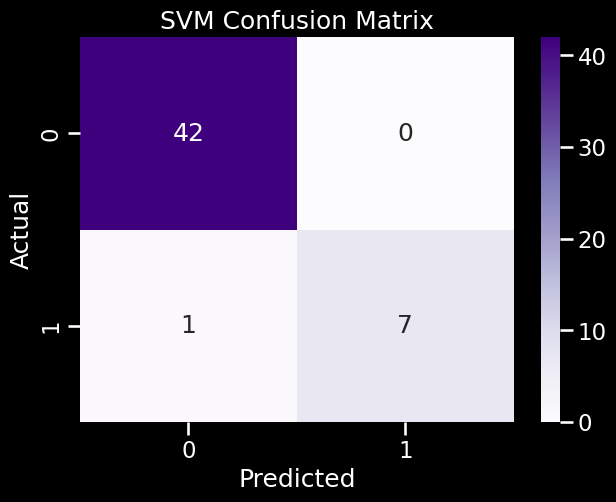

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(
    y_test,
    svm_preds
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<!-- Atom Purple -->

<div style="
background:linear-gradient(90deg,#F7F0FF,#EEE4FF);
padding:15px;
border-radius:15px;
border-left:6px solid #C678DD;
color:#4D3756;
">

# 🌲 Random Forest

Random Forest combines multiple decision trees.
The ensemble approach often improves classification performance.
</div>

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_preds = rf_model.predict(
    X_test
)

# Evaluation

In [73]:
acc_log = accuracy_score(
    y_test,
    log_preds
)

acc_svm = accuracy_score(
    y_test,
    svm_preds
)

acc_rf = accuracy_score(
    y_test,
    rf_preds
)

In [74]:
precision_log = precision_score(
    y_test,
    log_preds
)

In [75]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

C:\Users\Arian\AppData\Local\Temp\ipykernel_22248\2041995034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


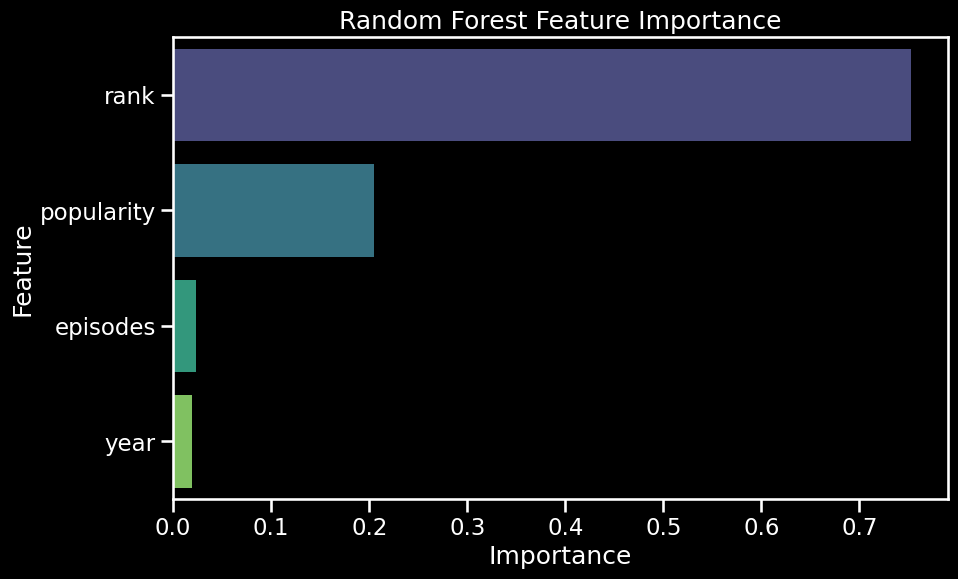

In [76]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

<!-- Dracula Green -->

<div style="
background:linear-gradient(90deg,#EFFFF2,#DDFBE5);
padding:15px;
border-radius:15px;
border-left:6px solid #50FA7B;
color:#245235;
">

# 📏 Confusion Matrix

The confusion matrix compares predicted labels with actual labels.
It highlights correct and incorrect classifications.

</div>

In [77]:
cm = confusion_matrix(
    y_test,
    rf_preds
)

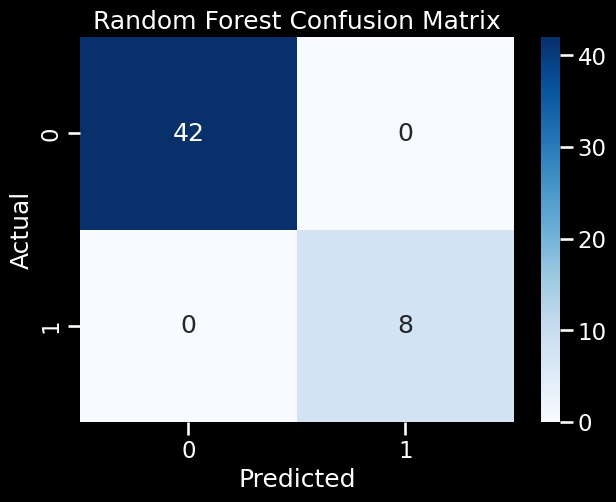

In [78]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

<div style="
background:linear-gradient(90deg,#EAF4FF,#F5F9FF);
padding:15px;
border-radius:15px;
border-left:6px solid #58A6FF;
color:#2D3B4D;
">

# 📊 Model Accuracy Comparison

The classification performance of multiple models is compared.
Higher values indicate better predictive accuracy.

</div>

In [79]:
comparison_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy":[
        acc_log,
        acc_svm,
        acc_rf
    ]
})

C:\Users\Arian\AppData\Local\Temp\ipykernel_22248\2944945485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


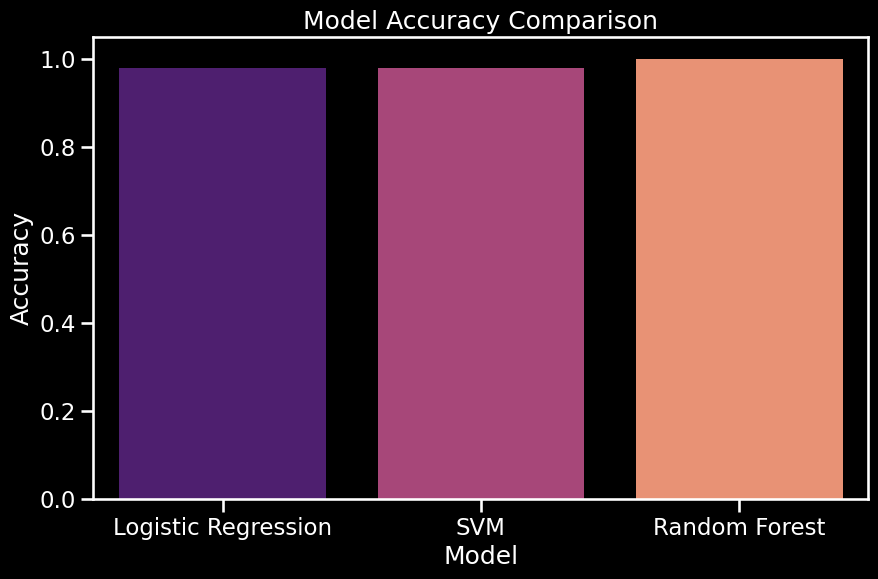

In [80]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    palette="magma"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

<div style="
background:linear-gradient(90deg,#F7F0FF,#EEE4FF);
padding:15px;
border-radius:15px;
border-left:6px solid #C678DD;
color:#4D3756;
">

## Conclusion

The chart identifies the strongest classification model based on accuracy.

</div>

In [83]:
df.shape

(250, 11)

In [84]:
df.columns

Index(['title', 'score', 'episodes', 'rank', 'popularity', 'year', 'synopsis',
       'kmeans_cluster', 'dbscan_cluster', 'hdbscan_cluster', 'high_rated'],
      dtype='object')

In [85]:
df["high_rated"].value_counts()

high_rated
0    208
1     42
Name: count, dtype: int64

In [86]:
%who

CYAN	 DBSCAN	 KMeans	 LogisticRegression	 PCA	 PINK	 PURPLE	 RandomForestClassifier	 SVC	 
StandardScaler	 X	 X_pca	 X_scaled	 X_test	 X_train	 YELLOW	 acc_log	 acc_rf	 
acc_svm	 accuracy_score	 all_anime	 anime	 anime_info	 anime_list	 clusterer	 clusters	 cm	 
cm_svm	 col	 comparison_df	 confusion_matrix	 data	 dbscan	 dbscan_clusters	 dendrogram	 df	 
f1_score	 features	 first_anime	 g	 genres	 hdbscan	 hdbscan_clusters	 importance_df	 inertia	 
k	 kmeans	 linkage	 linked	 log_model	 log_preds	 model	 page	 pca	 
pd	 plt	 precision_log	 precision_score	 pred	 recall_score	 requests	 response	 rf_model	 
rf_preds	 scaler	 scatter	 sns	 svm_model	 svm_preds	 time	 train_test_split	 url	 
var	 variables	 y	 y_test	 y_train	 


In [89]:
def recommend_cluster(title):

    cluster = df.loc[
        df["title"] == title,
        "kmeans_cluster"
    ].values[0]

    return df[
        df["kmeans_cluster"] == cluster
    ][
        ["title","score"]
    ].head(10)

In [88]:
#test
recommend_cluster(
    "Cowboy Bebop"
)

,title,score
0,Cowboy Bebop,8.75
1,Cowboy Bebop: Tengoku no Tobira,8.38
2,Trigun,8.22
6,Hachimitsu to Clover,7.98
8,Initial D Fourth Stage,8.18
9,Monster,8.89
11,One Piece,8.73
14,School Rumble,7.88
16,Texhnolyze,7.76
18,Yakitate!! Japan,7.90


<h1 align="center">🎌 Anime Recommendation Demo</h1>

<p align="center">
Anime recommendations can be generated using KMeans clusters.<br>
Anime within the same cluster are assumed to share similar characteristics.
</p>

<table align="center">
<tr>
<td><img src="1-miku.jpg" width="250" height="800"></td>
<td><img src="2-bleach.jpg" width="250" height="300"></td>
<td><img src="3-shizuku.jpg" width="250" height="300"></td>
<td><img src="4-art.jpg" width="250" height="300"></td>
</tr>
</table>